In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("netflix_titles.csv")

# quick overview
print(df.shape)
print(df.columns)
df.head()

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df = df.dropna(subset=['date_added'])
df['rating'] = df['rating'].fillna('Not Rated')
df = df.dropna(subset=['duration'])

In [5]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [6]:
df.info()
df.describe()
df['type'].value_counts()

<class 'pandas.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8794 non-null   str  
 1   type          8794 non-null   str  
 2   title         8794 non-null   str  
 3   director      8794 non-null   str  
 4   cast          8794 non-null   str  
 5   country       8794 non-null   str  
 6   date_added    8794 non-null   str  
 7   release_year  8794 non-null   int64
 8   rating        8794 non-null   str  
 9   duration      8794 non-null   str  
 10  listed_in     8794 non-null   str  
 11  description   8794 non-null   str  
dtypes: int64(1), str(11)
memory usage: 893.1 KB


type
Movie      6128
TV Show    2666
Name: count, dtype: int64

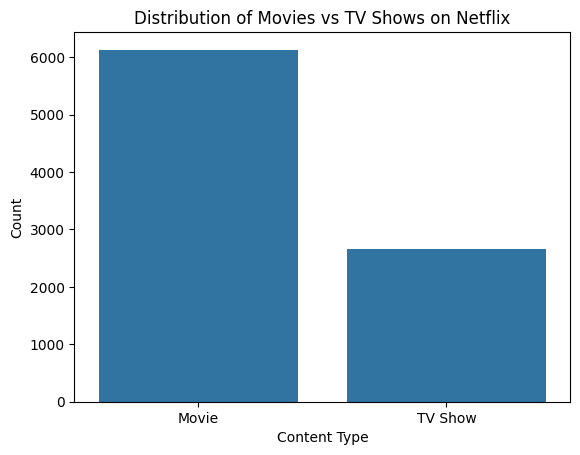

In [7]:
sns.countplot(data=df, x="type")

plt.title("Distribution of Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

In [9]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

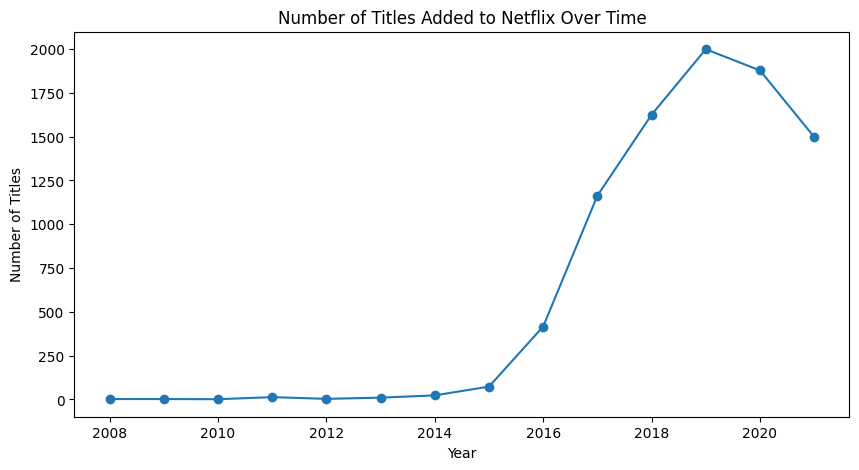

In [10]:
content_by_year = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
content_by_year.plot(kind='line', marker='o')

plt.title("Number of Titles Added to Netflix Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

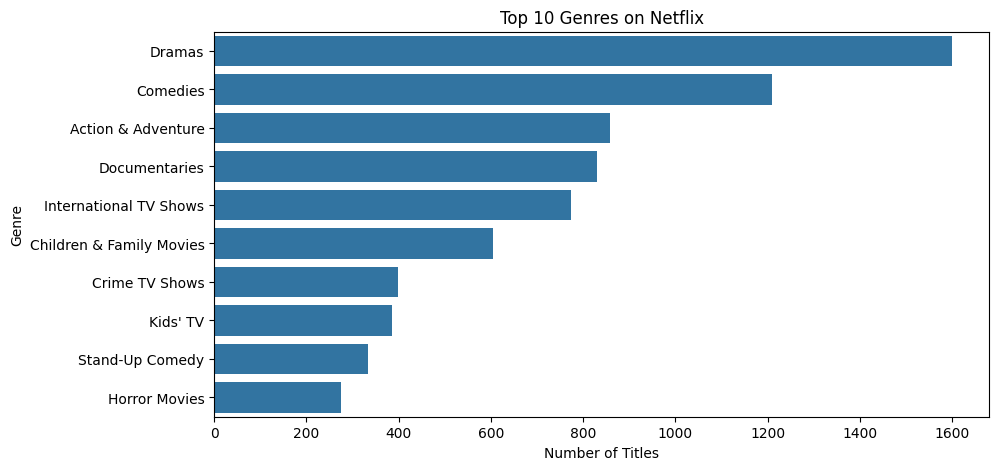

In [11]:
df['main_genre'] = df['listed_in'].apply(lambda x: x.split(",")[0])

top_genres = df['main_genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

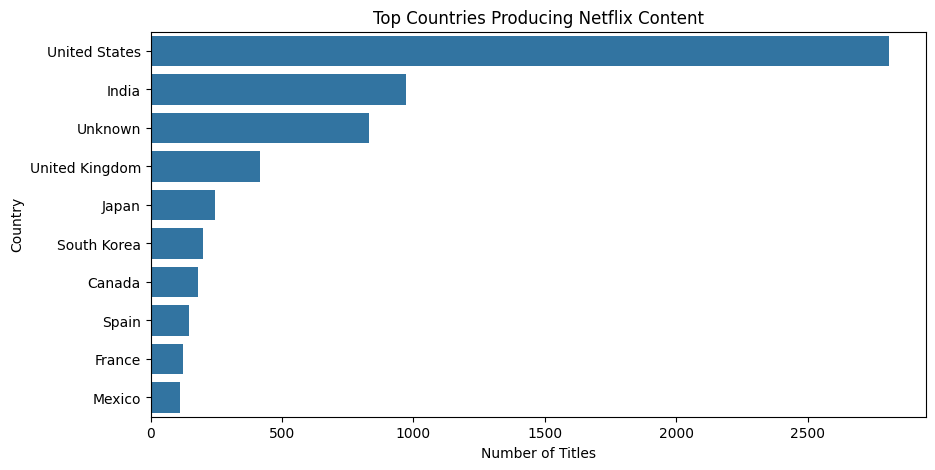

In [12]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

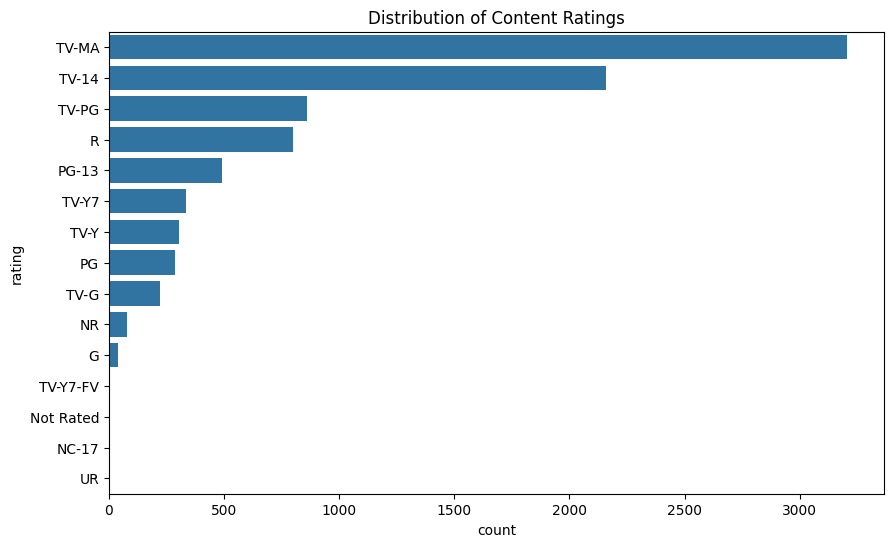

In [13]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index)

plt.title("Distribution of Content Ratings")

plt.show()

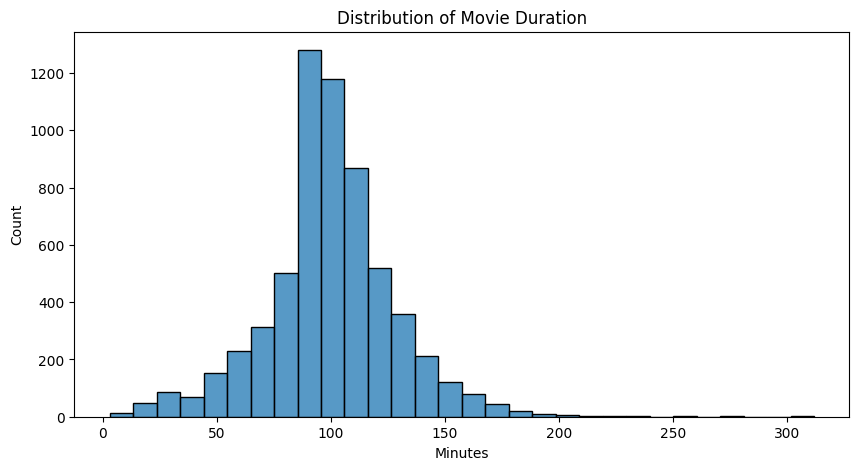

In [15]:
movies = df[df['type'] == 'Movie']
movies['duration'] = movies['duration'].str.replace(' min','').astype(int)
plt.figure(figsize=(10,5))

sns.histplot(movies['duration'], bins=30)

plt.title("Distribution of Movie Duration")
plt.xlabel("Minutes")

plt.show()